In [1]:
import os
import sys

import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
from ml.data_loader import load_train_test_data

X_train, X_test, y_train, y_test = load_train_test_data()

In [4]:
model = joblib.load("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\ml\\models\\xgboost.pkl")

In [5]:
explainer = shap.TreeExplainer(model)

In [6]:
shap_values = explainer.shap_values(X_test)

In [7]:
print(shap_values.shape)

(56746, 30)


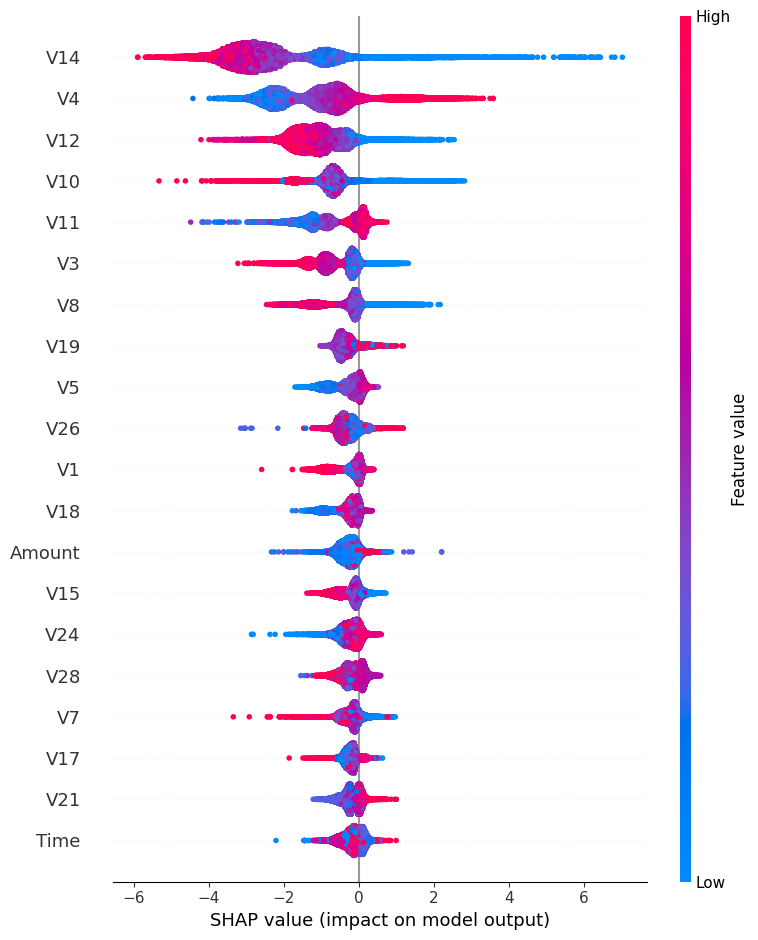

In [8]:
shap.summary_plot(shap_values, X_test)

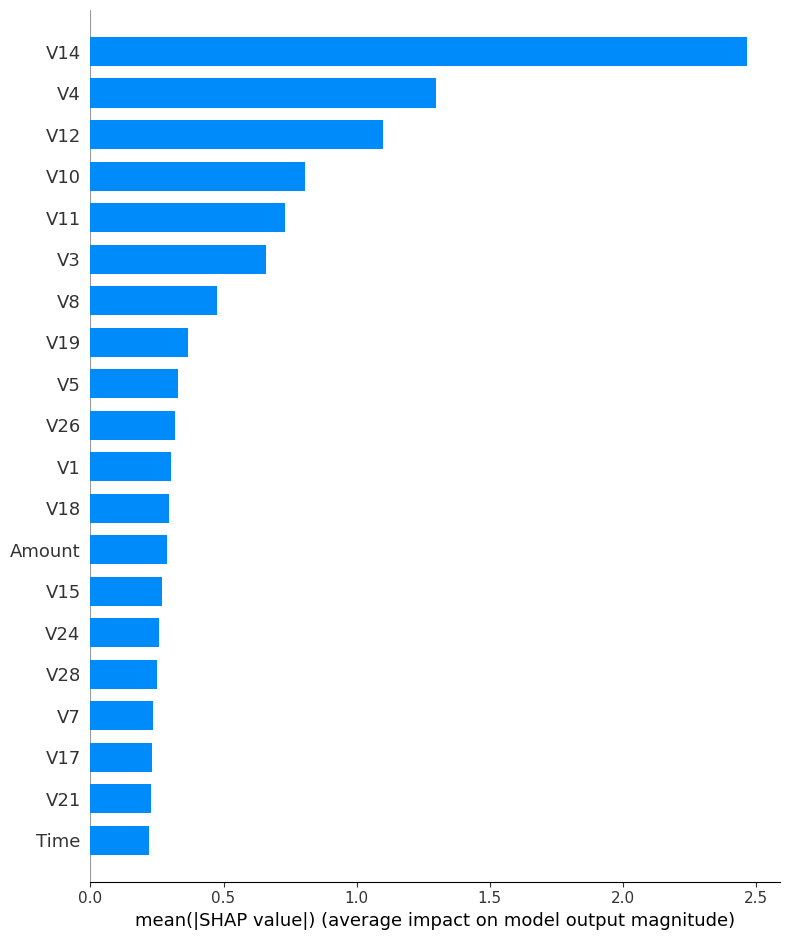

In [10]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [11]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

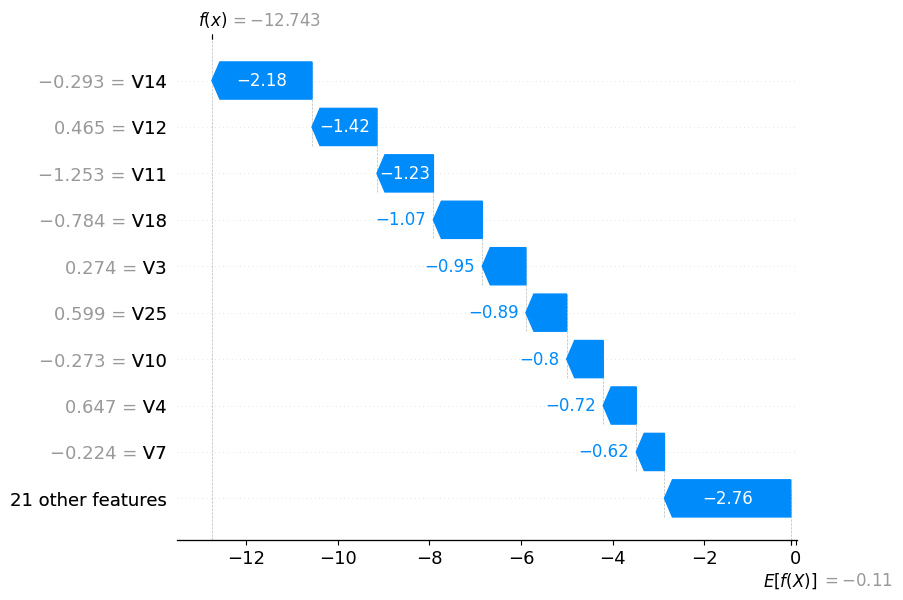

In [12]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

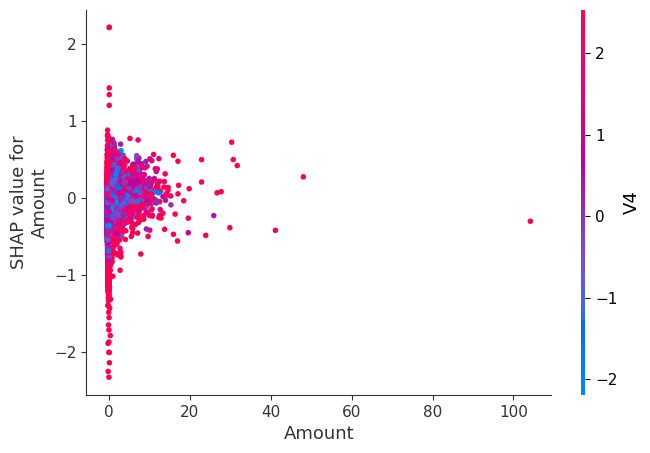

In [13]:
shap.dependence_plot(
    "Amount",
    shap_values,
    X_test
)

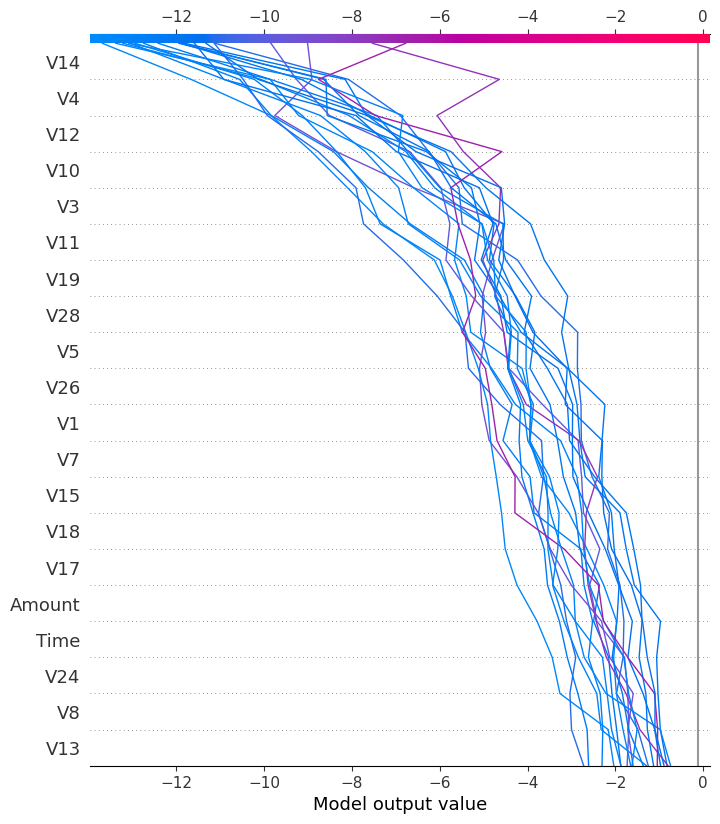

In [14]:
shap.decision_plot(
    explainer.expected_value,
    shap_values[:20],
    X_test.iloc[:20]
)

In [15]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, show=False)

plt.tight_layout()

plt.savefig("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\ml\\artifacts\\shap_summary.png", dpi=300)

plt.close()

In [16]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig("C:\\Users\\vipul\\Desktop\\Fraud_Detection\\ml\\artifacts\\shap_bar.png", dpi=300)

plt.close()